In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold


2026-01-07 06:17:15.602382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767766635.615113      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767766635.619073      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 06:17:15.635162: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
train = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/train.csv')
test = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/test.csv')
sub = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/sample_submission.csv')
print(train.head())
print(test.head())
print(sub.head())


                     Patient  Weeks   FVC    Percent  Age   Sex SmokingStatus
0  ID00133637202223847701934     -2  3195  92.856312   83  Male  Never smoked
1  ID00133637202223847701934      2  3203  93.088817   83  Male  Never smoked
2  ID00133637202223847701934      4  3097  90.008138   83  Male  Never smoked
3  ID00133637202223847701934      6  3171  92.158800   83  Male  Never smoked
4  ID00133637202223847701934      8  3115  90.531272   83  Male  Never smoked
                     Patient  Weeks   FVC    Percent  Age     Sex  \
0  ID00014637202177757139317      0  3807  90.076661   56    Male   
1  ID00019637202178323708467     13  2100  92.858722   83  Female   
2  ID00047637202184938901501      2  3313  89.929425   68    Male   
3  ID00082637202201836229724     19  2918  99.794802   49  Female   
4  ID00126637202218610655908     18  2375  59.375000   78    Male   

      SmokingStatus  
0         Ex-smoker  
1         Ex-smoker  
2         Ex-smoker  
3  Currently smokes  
4      

In [3]:
train.drop_duplicates(keep=False, inplace=True, subset=['Patient','Weeks'])

sub['Patient'] = sub['Patient_Week'].apply(lambda x:x.split('_')[0])
sub['Weeks'] = sub['Patient_Week'].apply(lambda x: int(x.split('_')[-1]))
sub =  sub[['Patient','Weeks','Confidence','Patient_Week']]
sub = sub.merge(test.drop('Weeks', axis=1), on="Patient")

print(train.shape, test.shape, sub.shape)


(1380, 7) (18, 7) (1908, 9)


<class 'pandas.core.frame.DataFrame'>
Index: 1380 entries, 0 to 1391
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient        1380 non-null   object 
 1   Weeks          1380 non-null   int64  
 2   FVC            1380 non-null   int64  
 3   Percent        1380 non-null   float64
 4   Age            1380 non-null   int64  
 5   Sex            1380 non-null   object 
 6   SmokingStatus  1380 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 86.2+ KB
None


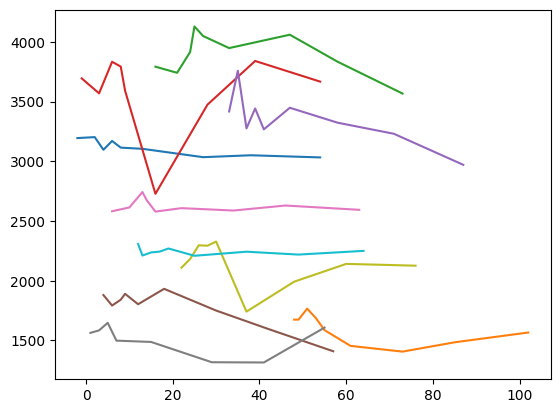

In [4]:
print(train.info())

patient_ids = train.Patient.unique()

for i in range(0,10):
    
    single_patient = train[train['Patient'] == patient_ids[i]]
#     print(single_patient)


    plt.plot(single_patient['Weeks'], single_patient['FVC'])


In [5]:
# Clean and wranglinate the data

train['WHERE'] = 'train'
test['WHERE'] = 'val'
sub['WHERE'] = 'test'
data = train.append([test, sub])


data['min_week'] = data['Weeks']
data.loc[data.WHERE=='test','min_week'] = np.nan
data['min_week'] = data.groupby('Patient')['min_week'].transform('min')


base = data.loc[data.Weeks == data.min_week]
base = base[['Patient', 'FVC']].copy()
base.columns = ['Patient','min_FVC']
base['nb'] = 1
base['nb'] = base.groupby('Patient')['nb'].transform('cumsum')
base = base[base.nb == 1]
base.drop('nb', axis=1, inplace=True)


data = data.merge(base, on='Patient', how='left')
data['base_week'] = data['Weeks'] - data['min_week']
del base


COLS = ['Sex','SmokingStatus'] #,'Age'
FE = []
for col in COLS:
    for mod in data[col].unique():
        FE.append(mod)
        data[mod] = (data[col] == mod).astype(int)
        

print(data.groupby('Patient').head())
data['age'] = (data['Age'] - data['Age'].min()) / (data['Age'].max() - data['Age'].min() )
data['BASE'] = (data['min_FVC'] - data['min_FVC'].min()) / (data['min_FVC'].max() - data['min_FVC'].min())
data['week'] = (data['base_week'] - data['base_week'].min()) / (data['base_week'].max() - data['base_week'].min())
data['percent'] = (data['Percent'] - data['Percent'].min()) / (data['Percent'].max() - data['Percent'].min())
FE += ['age','percent','week','BASE']
print(FE)


train = data.loc[data.WHERE=='train']
test = data.loc[data.WHERE=='val']
sub = data.loc[data.WHERE=='test']
del data



train.shape, test.shape, sub.shape


AttributeError: 'DataFrame' object has no attribute 'append'

In [6]:
C1, C2 = tf.constant(70, dtype='float32'), tf.constant(1000, dtype="float32")


def score(y_true, y_pred):
    tf.dtypes.cast(y_true, tf.float32)
    tf.dtypes.cast(y_pred, tf.float32)
    sigma = y_pred[:, 2] - y_pred[:, 0]
    fvc_pred = y_pred[:, 1]
    
    sigma_clip = tf.maximum(sigma, C1)
    delta = tf.abs(y_true[:, 0] - fvc_pred)
    delta = tf.minimum(delta, C2)
    sq2 = tf.sqrt( tf.dtypes.cast(2, dtype=tf.float32) )
    metric = (delta / sigma_clip)*sq2 + tf.math.log(sigma_clip* sq2)
    return tf.keras.backend.mean(metric)


def qloss(y_true, y_pred):
    # Pinball loss for multiple quantiles
    qs = [0.2, 0.50, 0.8]
    q = tf.constant(np.array([qs]), dtype=tf.float32)
    e = y_true - y_pred
    v = tf.maximum(q*e, (q-1)*e)
    return tf.keras.backend.mean(v)


def mloss(_lambda):
    def loss(y_true, y_pred):
        return _lambda * qloss(y_true, y_pred) + (1 - _lambda)*score(y_true, y_pred)
    return loss


def make_model(nh):
    z = tf.keras.layers.Input((nh,), name="Patient")
    x = tf.keras.layers.Dense(100, activation="relu", name="d1")(z)
    x = tf.keras.layers.Dense(100, activation="relu", name="d2")(x)
    p1 = tf.keras.layers.Dense(3, activation="linear", name="p1")(x)
    p2 = tf.keras.layers.Dense(3, activation="relu", name="p2")(x)
    preds = tf.keras.layers.Lambda(lambda x: x[0] + tf.cumsum(x[1], axis=1), 
                     name="preds")([p1, p2])
    
    model = tf.keras.models.Model(z, preds, name="definitely_not_a_CNN")
    model.compile(loss=mloss(0.8), optimizer=tf.keras.optimizers.Adam(lr=0.1, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.01, amsgrad=False), metrics=[score])
    return model


2026-01-07 06:17:22.826480: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767766642.834826      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


In [7]:
y = train['FVC'].values
z = train[FE].values
ze = sub[FE].values
nh = z.shape[1]
pe = np.zeros((ze.shape[0], 3))
pred = np.zeros((z.shape[0], 3))

net = make_model(nh)
print(net.summary())
print(net.count_params())


NameError: name 'FE' is not defined

In [8]:
NFOLD = 5
kf = KFold(n_splits=NFOLD)


In [9]:
%%time
cnt = 0
EPOCHS = 800
BATCH_SIZE=128

for tr_idx, val_idx in kf.split(z):
    cnt += 1
    print(f"FOLD {cnt}")
    net = make_model(nh)
    net.fit(z[tr_idx], y[tr_idx], batch_size=BATCH_SIZE, epochs=EPOCHS, 
            validation_data=(z[val_idx], y[val_idx]), verbose=0) #
    print("train", net.evaluate(z[tr_idx], y[tr_idx], verbose=0, batch_size=BATCH_SIZE))
    print("val", net.evaluate(z[val_idx], y[val_idx], verbose=0, batch_size=BATCH_SIZE))
    print("predict val...")
    pred[val_idx] = net.predict(z[val_idx], batch_size=BATCH_SIZE, verbose=0)
    print("predict test...")
    pe += net.predict(ze, batch_size=BATCH_SIZE, verbose=0) / NFOLD


NameError: name 'z' is not defined

In [10]:
sigma_opt = mean_absolute_error(y, pred[:, 1])
unc = pred[:,2] - pred[:, 0]
sigma_mean = np.mean(unc)


sub['FVC1'] = 0.996*pe[:, 1]
sub['Confidence1'] = pe[:, 2] - pe[:, 0]
subm = sub[['Patient_Week','FVC','Confidence','FVC1','Confidence1']].copy()


subm.loc[~subm.FVC1.isnull(),'FVC'] = subm.loc[~subm.FVC1.isnull(),'FVC1']
if sigma_mean<70:
    subm['Confidence'] = sigma_opt
else:
    subm.loc[~subm.FVC1.isnull(),'Confidence'] = subm.loc[~subm.FVC1.isnull(),'Confidence1']


NameError: name 'pred' is not defined

In [11]:
otest = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/test.csv')
for i in range(len(otest)):
    subm.loc[subm['Patient_Week']==otest.Patient[i]+'_'+str(otest.Weeks[i]), 'FVC'] = otest.FVC[i]
    subm.loc[subm['Patient_Week']==otest.Patient[i]+'_'+str(otest.Weeks[i]), 'Confidence'] = 0.1
    

subm[["Patient_Week","FVC","Confidence"]].to_csv("submission.csv", index=False)


NameError: name 'subm' is not defined